In [4]:
import pandas as pd
import numpy as np

# Column names for Cleveland Heart Disease dataset
columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

# Load the processed Cleveland dataset
df = pd.read_csv(
    "/content/processed.cleveland.data",
    header=None,
    names=columns
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


Check missing values

In [5]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


Check duplicate rows

In [6]:
# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


Check the data types

In [7]:
# Check data types
print("Data types of each column:")
print(df.dtypes)

Data types of each column:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca           object
thal         object
target        int64
dtype: object


Convert ca and thal to numeric

In [8]:
# Convert categorical columns to numeric
df['ca'] = pd.to_numeric(df['ca'], errors='coerce')
df['thal'] = pd.to_numeric(df['thal'], errors='coerce')

# Check data types again
print(df.dtypes)

age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object


Check missing values again

In [9]:
# Check for missing values after conversion
print("Missing values after conversion:")
print(df.isnull().sum())

Missing values after conversion:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


Fill missing values

In [10]:
# Fill missing values with the median
df['ca'] = df['ca'].fillna(df['ca'].median())
df['thal'] = df['thal'].fillna(df['thal'].median())

# Check again
print("Missing values after filling:")
print(df.isnull().sum())

Missing values after filling:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


See the target distribution

Target value counts:
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


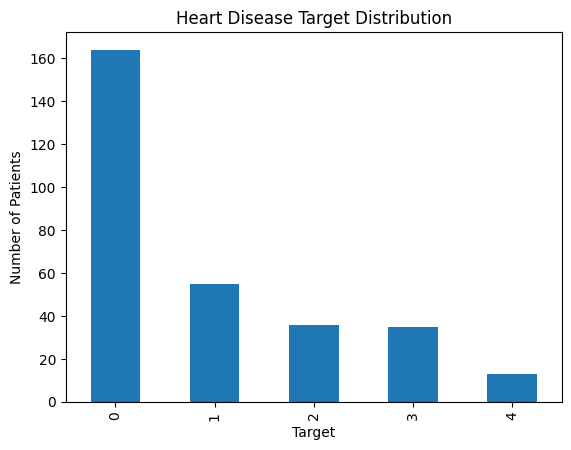

In [11]:
# Check target distribution

print("Target value counts:")
print(df['target'].value_counts())

# Plot target distribution
import matplotlib.pyplot as plt

df['target'].value_counts().plot(kind='bar')
plt.title('Heart Disease Target Distribution')
plt.xlabel('Target')
plt.ylabel('Number of Patients')
plt.show()

Feature correlation heatmap

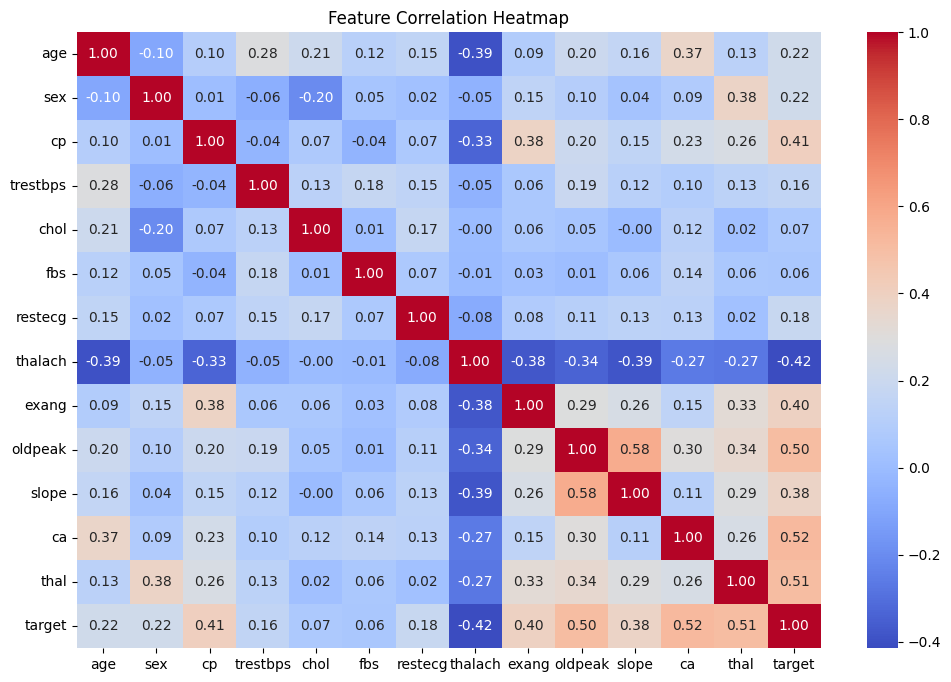

In [12]:
# Correlation between features

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Feature Correlation Heatmap')
plt.show()

Prepare X and y

In [13]:
# Define features and target

X = df.drop('target', axis=1)
y = df['target']

print("Features (X):", X.shape)
print("Target (y):", y.shape)

Features (X): (303, 13)
Target (y): (303,)


Train/Test Split

In [14]:
# Split the dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features :", X_test.shape)
print("Training target  :", y_train.shape)
print("Testing target   :", y_test.shape)

Training features: (242, 13)
Testing features : (61, 13)
Training target  : (242,)
Testing target   : (61,)


Train the models

In [15]:
# Import machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Create the models
logistic_model = LogisticRegression(max_iter=1000)
decision_tree = DecisionTreeClassifier(random_state=42)
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train Logistic Regression
logistic_model.fit(X_train, y_train)

# Train Decision Tree
decision_tree.fit(X_train, y_train)

# Train Random Forest
random_forest.fit(X_train, y_train)

print("All three models trained successfully!")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


All three models trained successfully!


Test the 3 models

In [16]:
# Make predictions using all three models

y_pred_lr = logistic_model.predict(X_test)
y_pred_dt = decision_tree.predict(X_test)
y_pred_rf = random_forest.predict(X_test)

print("Predictions completed successfully!")

Predictions completed successfully!


In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics
results = {
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr, average="weighted"),
        precision_score(y_test, y_pred_dt, average="weighted"),
        precision_score(y_test, y_pred_rf, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr, average="weighted"),
        recall_score(y_test, y_pred_dt, average="weighted"),
        recall_score(y_test, y_pred_rf, average="weighted")
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr, average="weighted"),
        f1_score(y_test, y_pred_dt, average="weighted"),
        f1_score(y_test, y_pred_rf, average="weighted")
    ]
}

# Create comparison table
comparison = pd.DataFrame(results)

print("Model Performance Comparison:")
display(comparison.round(4))

Model Performance Comparison:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.6230,0.5755,0.6230,0.5961
1,Decision Tree,0.4590,0.4609,0.4590,0.4588
2,Random Forest,0.5246,0.4222,0.5246,0.4679


In [18]:
# Convert heart disease target into binary classification
# 0 = No heart disease
# 1,2,3,4 = Heart disease

df['target'] = (df['target'] > 0).astype(int)

print("Target distribution:")
print(df['target'].value_counts())

Target distribution:
target
0    164
1    139
Name: count, dtype: int64


In [19]:
# Separate features and target

X = df.drop('target', axis=1)
y = df['target']

print("Features (X):", X.shape)
print("Target (y):", y.shape)

Features (X): (303, 13)
Target (y): (303,)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (242, 13)
Testing features: (61, 13)
Training target: (242,)
Testing target: (61,)


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Create models
logistic_model = LogisticRegression(max_iter=5000)
decision_tree = DecisionTreeClassifier(random_state=42)
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train models
logistic_model.fit(X_train, y_train)
decision_tree.fit(X_train, y_train)
random_forest.fit(X_train, y_train)

print("All three models trained successfully!")

All three models trained successfully!


In [22]:
# Make predictions

y_pred_lr = logistic_model.predict(X_test)
y_pred_dt = decision_tree.predict(X_test)
y_pred_rf = random_forest.predict(X_test)

print("Predictions completed successfully!")

Predictions completed successfully!


In [23]:
from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:",
      round(accuracy_score(y_test, y_pred_lr), 4))

print("Decision Tree Accuracy:",
      round(accuracy_score(y_test, y_pred_dt), 4))

print("Random Forest Accuracy:",
      round(accuracy_score(y_test, y_pred_rf), 4))

Logistic Regression Accuracy: 0.8689
Decision Tree Accuracy: 0.7377
Random Forest Accuracy: 0.8852


In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate metrics for all models

models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf
}

for name, predictions in models.items():
    print("\n" + "=" * 40)
    print(name)
    print("=" * 40)

    print("Precision:",
          round(precision_score(y_test, predictions), 4))

    print("Recall:",
          round(recall_score(y_test, predictions), 4))

    print("F1-Score:",
          round(f1_score(y_test, predictions), 4))


Logistic Regression
Precision: 0.8125
Recall: 0.9286
F1-Score: 0.8667

Decision Tree
Precision: 0.6765
Recall: 0.8214
F1-Score: 0.7419

Random Forest
Precision: 0.8387
Recall: 0.9286
F1-Score: 0.8814


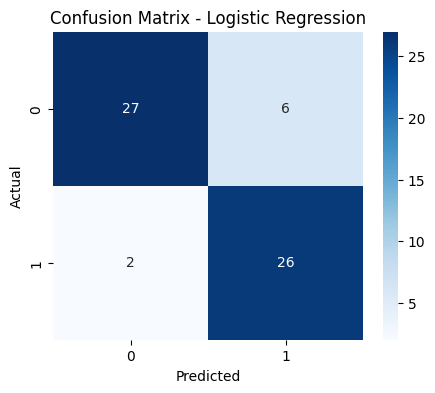

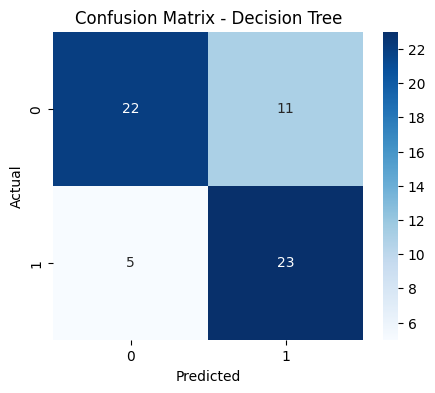

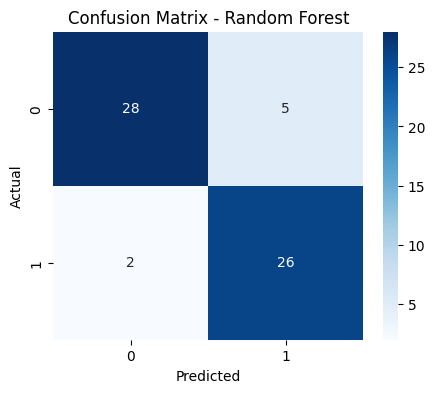

In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrices
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Logistic Regression
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Decision Tree
plt.figure(figsize=(5, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Random Forest
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

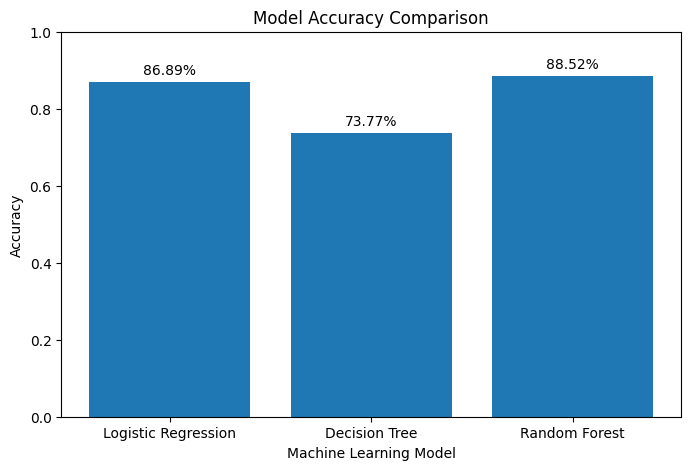

In [26]:
import matplotlib.pyplot as plt

# Model names and accuracy values
model_names = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
]

accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf)
]

# Create bar chart
plt.figure(figsize=(8, 5))
plt.bar(model_names, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

# Display accuracy values on bars
for i, accuracy in enumerate(accuracies):
    plt.text(i, accuracy + 0.02, f"{accuracy:.2%}",
             ha="center")

plt.show()

Feature Importance:


,Feature,Importance
7,thalach,0.135404
2,cp,0.127163
12,thal,0.122940
11,ca,0.100811
0,age,0.091327
9,oldpeak,0.089358
4,chol,0.088681
3,trestbps,0.080716
8,exang,0.050730
10,slope,0.046626


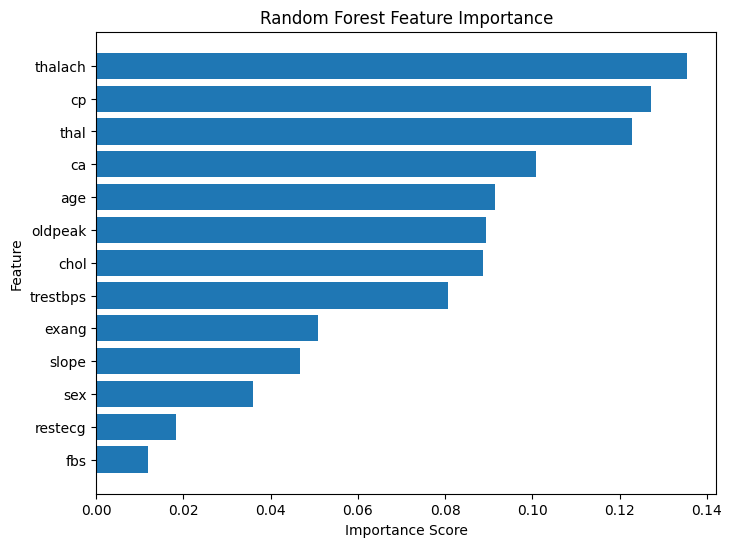


Top 3 Most Important Features:
    Feature  Importance
7   thalach    0.135404
2        cp    0.127163
12     thal    0.122940


In [27]:
# Random Forest Feature Importance

import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importance = random_forest.feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display all feature importance values
print("Feature Importance:")
display(feature_importance)

# Plot feature importance
plt.figure(figsize=(8, 6))
plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

# Display top 3 features
print("\nTop 3 Most Important Features:")
print(feature_importance.head(3))